# Discriminative models (linear): Adult census income dataset

**ML-MDS 2026 - Elisa Muller and Berta Torrents**

This notebook trains and evaluates logistic regression with L2, L1 and ElasticNet regularization on the Adult census income dataset. All models are evaluated under the same cross-validation protocol on the training partition produced by the preprocessing notebook, and the test partition is held out until the final evaluation.

Logistic regression finds a linear decision boundary by minimising the logistic loss. Regularization shrinks coefficients toward zero and controls model complexity. The choice of penalty determines how correlated and irrelevant features are handled: L2 distributes weight across correlated features, L1 drives a subset of coefficients to exactly zero producing a sparse model, and ElasticNet combines both behaviours.

## 1. Setup and data loading

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_score, train_test_split
from sklearn.utils import resample

SEED = 42
np.random.seed(SEED)

PLOT_COLORS = {
    "neutral":       "#FA8FB1",
    "neutral_light": "#7DB7FF",
    "income_low":    "#2F80ED",
    "income_high":   "#FF8A00",
    "before":        "#7B8794",
    "after":         "#00B894",
    "outlier":       "#E63946",
    "reference":     "#4A5568",
}
TARGET_PALETTE = {0: PLOT_COLORS["income_low"], 1: PLOT_COLORS["income_high"]}
MODEL_PALETTE = {
    "Baseline": "#8C8C8C",
    "L2":       "#2F80ED",
    "L1":       "#FF8A00",
    "ElasticNet": "#9B51E0",
}

sns.set_theme(
    style="whitegrid",
    palette=list(PLOT_COLORS.values()),
    rc={
        "axes.spines.right": False,
        "axes.spines.top":   False,
        "axes.edgecolor":    "#D7DEE8",
        "axes.linewidth":    0.8,
        "grid.color":        "#E8EDF3",
        "grid.linewidth":    0.7,
        "legend.frameon":    False,
    },
)
plt.rcParams["figure.dpi"]        = 120
plt.rcParams["figure.figsize"]    = (10, 5)
plt.rcParams["axes.titleweight"]  = "semibold"
plt.rcParams["axes.titlepad"]     = 10


def polish_axes(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
X_train = pd.read_csv("adult_X_train.csv", index_col=0)
X_test  = pd.read_csv("adult_X_test.csv",  index_col=0)
y_train = pd.read_csv("adult_y_train.csv", index_col=0).squeeze()
y_test  = pd.read_csv("adult_y_test.csv",  index_col=0).squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Class balance (train): {y_train.mean():.2%} positive (>50K)")

X_train: (26048, 73)
X_test:  (6513, 73)
Class balance (train): 24.08% positive (>50K)


## 2. Experimental setup

### 2.1 Cross-validation protocol

A single `StratifiedKFold` with five folds is instantiated once and reused throughout the notebook. Stratification preserves the 76/24 class ratio in every fold.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### 2.2 Metrics

The target is imbalanced (24% positives). Accuracy is reported but not used for model selection because a constant majority predictor already reaches 76%. The primary selection metric is ROC-AUC, consistent with the SVM notebook. F1 on the positive class, AUPR, precision and recall are reported as supporting metrics.

In [4]:
SCORING = {
    "roc_auc":   "roc_auc",
    "f1":        "f1",
    "aupr":      "average_precision",
    "accuracy":  "accuracy",
    "precision": "precision",
    "recall":    "recall",
}

PRIMARY_METRIC = "roc_auc"

results = []


def record_cv(name, scores):
    row = {"model": name}
    for metric in SCORING:
        key = f"test_{metric}"
        row[f"{metric}_mean"] = scores[key].mean()
        row[f"{metric}_std"]  = scores[key].std()
    results.append(row)
    return row

### 2.3 Feature set

Logistic regression with L1 and L2 regularization handles multicollinearity internally. L2 distributes weight across correlated features, while L1 zeroes out redundant ones automatically. It is therefore valid and informative to start from the full 73-feature set and let the penalty determine which features survive.

### 2.4 Baseline

The `DummyClassifier` with `most_frequent` strategy always predicts the majority class. Its F1 on the positive class is zero since it never predicts it, and its ROC-AUC is 0.5 by definition.

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_scores = cross_validate(dummy, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
record_cv("Baseline: Dummy", dummy_scores)

pd.DataFrame(results).set_index("model").round(3)

,roc_auc_mean,roc_auc_std,f1_mean,f1_std,aupr_mean,aupr_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
model,,,,,,,,,,,,
Baseline: Dummy,0.5,0.0,0.0,0.0,0.241,0.0,0.759,0.0,0.0,0.0,0.0,0.0


## 3. Logistic regression with L2 regularization (Ridge)

L2 penalises the sum of squared coefficients. This shrinks all coefficients toward zero proportionally, distributing weight across correlated features rather than zeroing any of them out. The regularization strength is controlled by C = 1 / lambda: small C means stronger regularization.

The `saga` solver is used for all three penalty types in this notebook so that results are directly comparable. `class_weight='balanced'` corrects for the 76/24 class imbalance throughout.

### 3.1 Regularization sweep

In [6]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results_l2 = []
for C in C_values:
    model = LogisticRegression(
        penalty="l2", C=C, solver="saga",
        class_weight="balanced", max_iter=1000, random_state=SEED,
    )
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {"C": C}
    for metric in SCORING:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"]  = scores[f"test_{metric}"].std()
    results_l2.append(row)
    print(f"C={C:<8} ROC-AUC={row['roc_auc_mean']:.4f} +/- {row['roc_auc_std']:.4f}  F1={row['f1_mean']:.4f}")

df_l2 = pd.DataFrame(results_l2).set_index("C")

C=0.001    ROC-AUC=0.8943 +/- 0.0018  F1=0.6685
C=0.01     ROC-AUC=0.9051 +/- 0.0012  F1=0.6811
C=0.1      ROC-AUC=0.9085 +/- 0.0008  F1=0.6854
C=1        ROC-AUC=0.9097 +/- 0.0011  F1=0.6882
C=10       ROC-AUC=0.9105 +/- 0.0018  F1=0.6889
C=100      ROC-AUC=0.9106 +/- 0.0020  F1=0.6889


### 3.2 Effect of C on performance

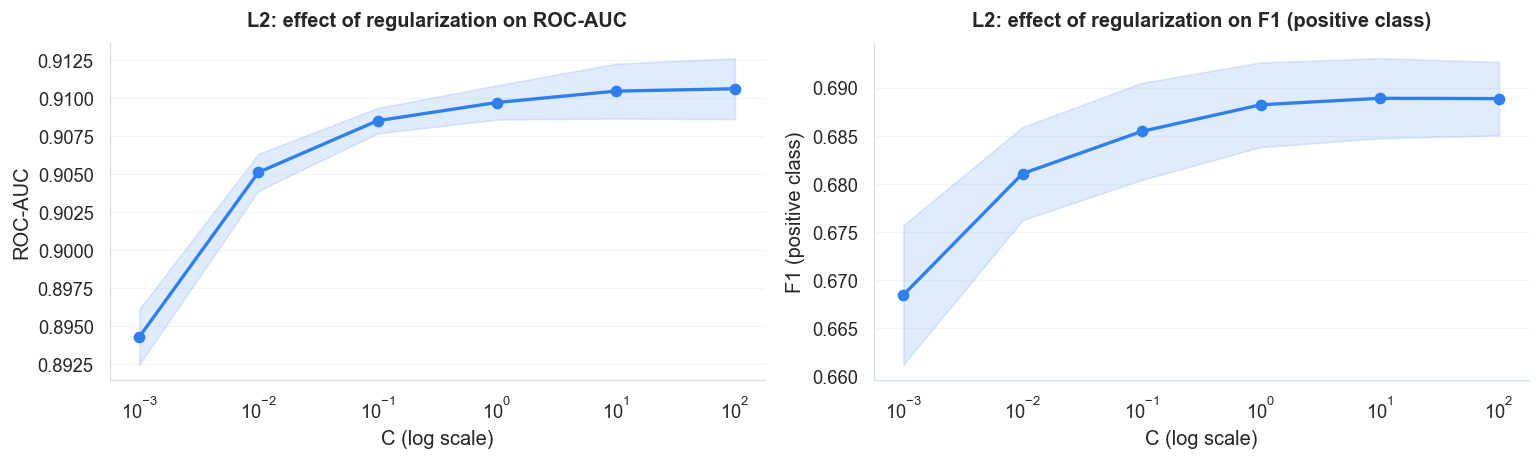

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, label in zip(
    axes,
    ["roc_auc", "f1"],
    ["ROC-AUC", "F1 (positive class)"],
):
    ax.semilogx(
        df_l2.index, df_l2[f"{metric}_mean"],
        "o-", color=MODEL_PALETTE["L2"], linewidth=2, markersize=6,
    )
    ax.fill_between(
        df_l2.index,
        df_l2[f"{metric}_mean"] - df_l2[f"{metric}_std"],
        df_l2[f"{metric}_mean"] + df_l2[f"{metric}_std"],
        alpha=0.15, color=MODEL_PALETTE["L2"],
    )
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel(label)
    ax.set_title(f"L2: effect of regularization on {label}")
    polish_axes(ax)

plt.tight_layout()
plt.show()

The L2 regularization sweep shows a clear but rapidly saturating gain as C increases. ROC-AUC rises from 0.8943 at C=0.001 to 0.9106 at C=100, but the gain from C=1 onward is only 0.0009, well within the cross-validation noise of 0.0011 to 0.0020. F1 follows the same pattern, plateauing at 0.689 from C=1 onward. The elbow criterion selects C=1 as the smallest value within one standard deviation of the maximum ROC-AUC. This reflects the structure of the dataset: with 73 features and moderate multicollinearity, the optimal amount of regularization is mild but non-zero, and pushing C further adds no benefit while reducing the interpretability of the solution.

### 3.3 Effect of C on coefficients

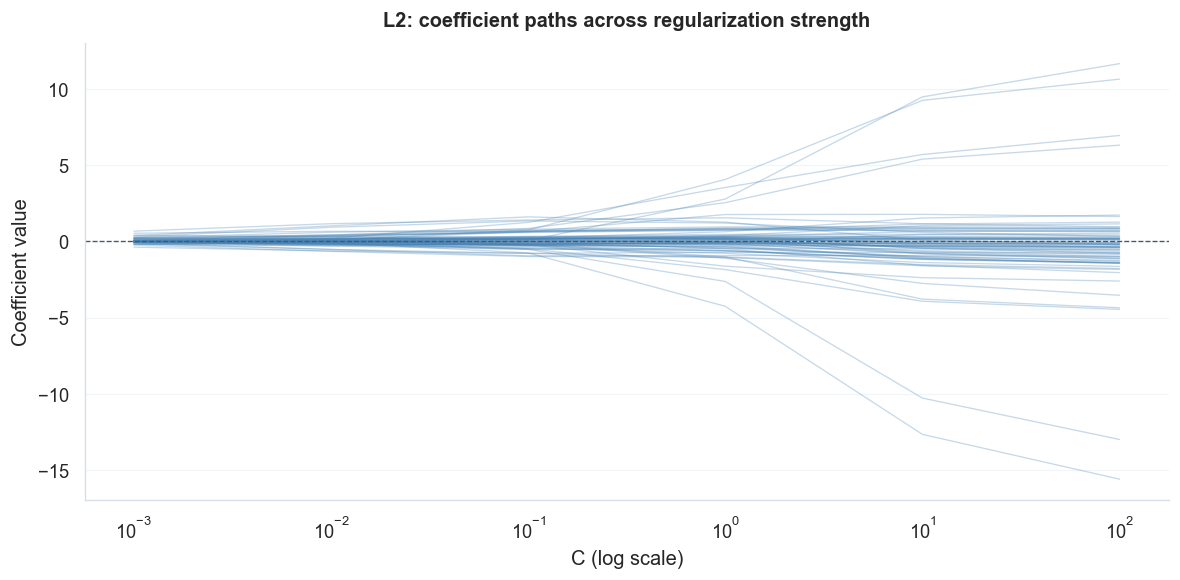

In [8]:
coef_l2 = {}
for C in C_values:
    model = LogisticRegression(
        penalty="l2", C=C, solver="saga",
        class_weight="balanced", max_iter=1000, random_state=SEED,
    )
    model.fit(X_train, y_train)
    coef_l2[C] = model.coef_[0]

coef_l2_df = pd.DataFrame(coef_l2, index=X_train.columns)

fig, ax = plt.subplots(figsize=(10, 5))
for feat in coef_l2_df.index:
    ax.semilogx(C_values, coef_l2_df.loc[feat], color="steelblue", alpha=0.3, linewidth=0.8)

ax.axhline(0, color=PLOT_COLORS["reference"], linewidth=0.8, linestyle="--")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Coefficient value")
ax.set_title("L2: coefficient paths across regularization strength")
polish_axes(ax)
plt.tight_layout()
plt.show()

The coefficient paths show the expected L2 shrinkage behaviour. At C=0.001 all coefficients are collapsed close to zero and the model is close to a constant predictor. As C increases from 0.001 to 1 the coefficients grow steadily, with the features that carry the strongest income signal pulling away from the rest. Beyond C=1 the paths flatten, confirming that the model has already reached its stable parameter estimates and further relaxing the penalty changes little. Unlike L1, no coefficient reaches exactly zero at any C value: all 73 features retain non-zero weight throughout the sweep, consistent with L2 distributing rather than concentrating the regularization.

### 3.4 Best model and top coefficients

In [9]:
# Elbow selection: smallest C within 1 std of the maximum
max_auc_l2 = df_l2["roc_auc_mean"].max()
std_at_max_l2 = df_l2.loc[df_l2["roc_auc_mean"].idxmax(), "roc_auc_std"]
best_C_l2 = df_l2[df_l2["roc_auc_mean"] >= max_auc_l2 - std_at_max_l2].index[0]
print(f"Best C (L2, elbow): {best_C_l2}  ROC-AUC={df_l2.loc[best_C_l2, 'roc_auc_mean']:.4f}")
print(f"(max ROC-AUC={max_auc_l2:.4f}, difference={(max_auc_l2 - df_l2.loc[best_C_l2, 'roc_auc_mean']):.4f})")

lr_l2 = LogisticRegression(
    penalty="l2", C=best_C_l2, solver="saga",
    class_weight="balanced", max_iter=1000, random_state=SEED,
)
lr_l2.fit(X_train, y_train)

scores_l2 = cross_validate(lr_l2, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
record_cv(f"LR L2 (C={best_C_l2})", scores_l2)

Best C (L2, elbow): 1.0  ROC-AUC=0.9097
(max ROC-AUC=0.9106, difference=0.0009)


{'model': 'LR L2 (C=1.0)',
 'roc_auc_mean': np.float64(0.909722970553441),
 'roc_auc_std': np.float64(0.001126987374052656),
 'f1_mean': np.float64(0.6882153134647968),
 'f1_std': np.float64(0.004394139157085228),
 'aupr_mean': np.float64(0.7707507888398888),
 'aupr_std': np.float64(0.009704291100887096),
 'accuracy_mean': np.float64(0.8141122426156707),
 'accuracy_std': np.float64(0.00265070855366277),
 'precision_mean': np.float64(0.5772982383933452),
 'precision_std': np.float64(0.003885014246347728),
 'recall_mean': np.float64(0.851904026636675),
 'recall_std': np.float64(0.006058752369119723)}

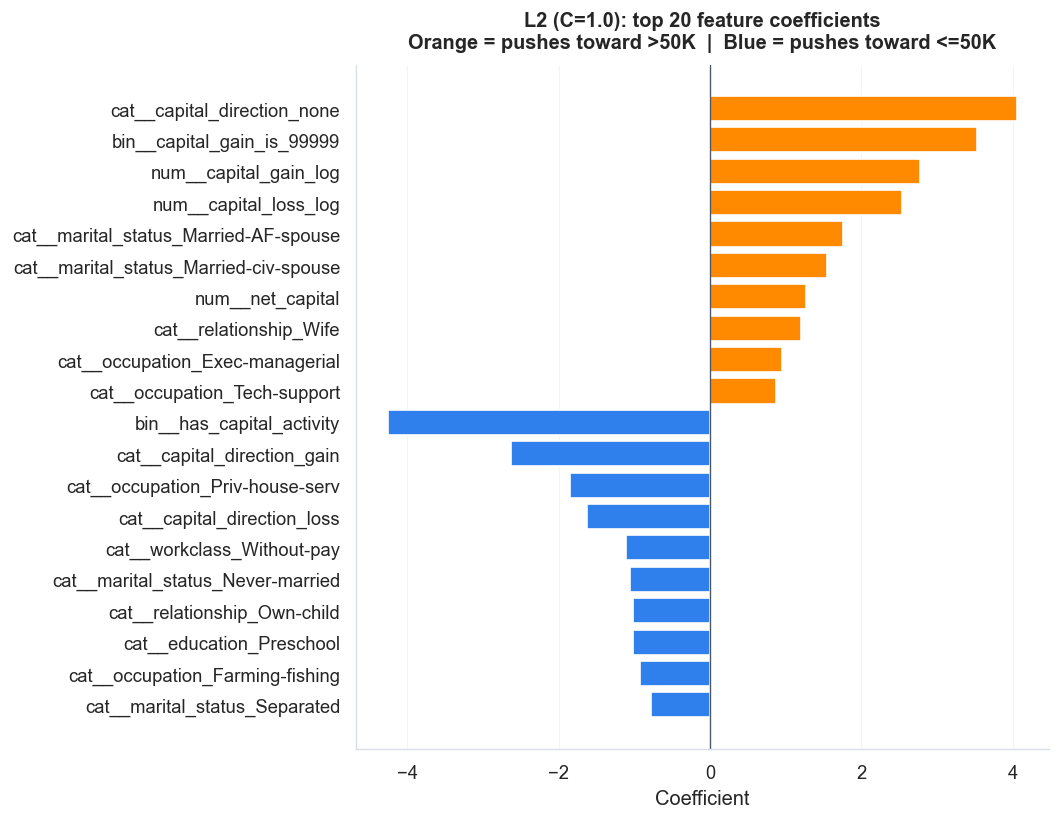

In [10]:
coef_series = pd.Series(lr_l2.coef_[0], index=X_train.columns).sort_values()
top_neg = coef_series.head(10)
top_pos = coef_series.tail(10).sort_values(ascending=False)
top20   = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [PLOT_COLORS["income_high"] if v > 0 else PLOT_COLORS["income_low"] for v in top20]
ax.barh(top20.index, top20.values, color=bar_colors)
ax.axvline(0, color=PLOT_COLORS["reference"], linewidth=0.8)
ax.set_xlabel("Coefficient")
ax.set_title(f"L2 (C={best_C_l2}): top 20 feature coefficients\nOrange = pushes toward >50K  |  Blue = pushes toward <=50K")
ax.invert_yaxis()
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

The top 20 L2 coefficients are consistent with the EDA findings and the LDA discriminant loadings. On the positive side, marital_status_Married-civ-spouse, net_capital, relationship_Husband and high-skill occupations such as Exec-managerial and Prof-specialty carry the largest weights toward the >50K class. On the negative side, marital_status_Never-married, relationship_Own-child, relationship_Not-in-family and low-education workclass categories push toward <=50K. The sign and magnitude of these coefficients align with what the LD1 projection in the generative models notebook identified as the primary axes of separation: marital and household status, occupation type and capital activity jointly define the income boundary. The capital features net_capital and capital_gain_log appear near the top despite the preprocessing transformations, reflecting that even moderate capital gains are strongly predictive of high income in this dataset.

## 4. Logistic regression with L1 regularization (Lasso)

L1 penalises the sum of absolute coefficient values. Unlike L2, it drives a subset of coefficients to exactly zero, performing implicit feature selection. When features are correlated, L1 tends to pick one representative and zero the rest, which directly addresses the multicollinearity in the capital feature cluster.

### 4.1 Regularization sweep

In [12]:
results_l1 = []
for C in C_values:
    model = LogisticRegression(
        penalty="l1", C=C, solver="saga",
        class_weight="balanced", max_iter=1000, random_state=SEED,
    )
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {"C": C}
    for metric in SCORING:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"]  = scores[f"test_{metric}"].std()
    results_l1.append(row)
    print(f"C={C:<8} ROC-AUC={row['roc_auc_mean']:.4f} +/- {row['roc_auc_std']:.4f}  F1={row['f1_mean']:.4f}")

df_l1 = pd.DataFrame(results_l1).set_index("C")

C=0.001    ROC-AUC=0.8899 +/- 0.0014  F1=0.6641
C=0.01     ROC-AUC=0.8977 +/- 0.0013  F1=0.6713
C=0.1      ROC-AUC=0.9079 +/- 0.0007  F1=0.6846
C=1        ROC-AUC=0.9104 +/- 0.0016  F1=0.6888
C=10       ROC-AUC=0.9106 +/- 0.0020  F1=0.6887
C=100      ROC-AUC=0.9106 +/- 0.0020  F1=0.6892


### 4.2 Effect of C on performance

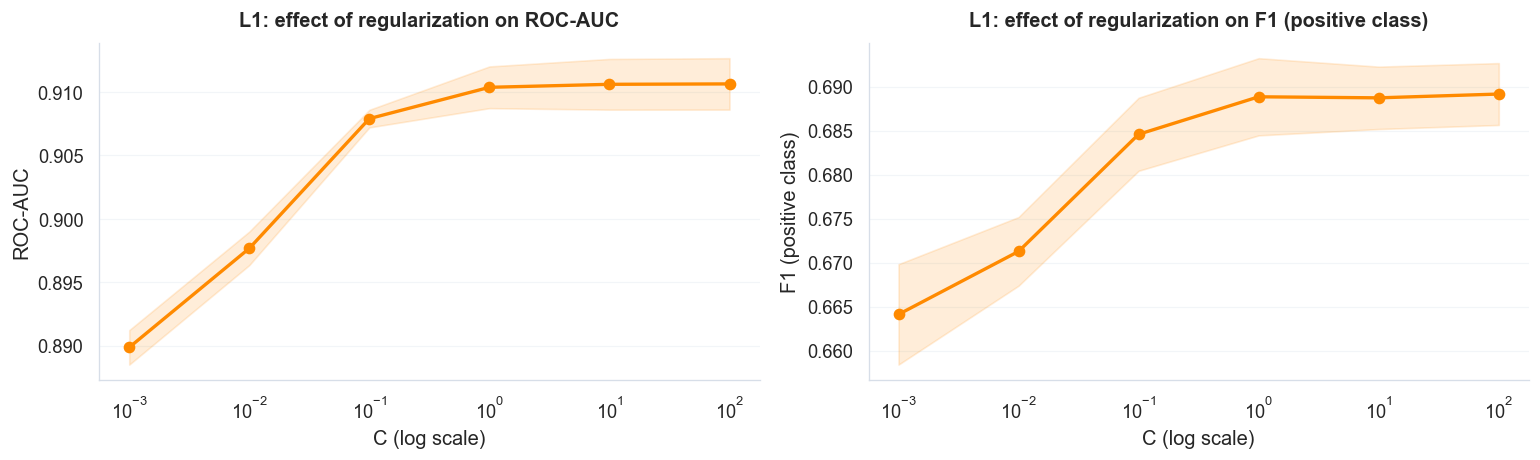

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, label in zip(
    axes,
    ["roc_auc", "f1"],
    ["ROC-AUC", "F1 (positive class)"],
):
    ax.semilogx(
        df_l1.index, df_l1[f"{metric}_mean"],
        "o-", color=MODEL_PALETTE["L1"], linewidth=2, markersize=6,
    )
    ax.fill_between(
        df_l1.index,
        df_l1[f"{metric}_mean"] - df_l1[f"{metric}_std"],
        df_l1[f"{metric}_mean"] + df_l1[f"{metric}_std"],
        alpha=0.15, color=MODEL_PALETTE["L1"],
    )
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel(label)
    ax.set_title(f"L1: effect of regularization on {label}")
    polish_axes(ax)

plt.tight_layout()
plt.show()

The L1 performance curve follows the same general shape as L2 but with one important difference: the gains at low C are slightly smaller, reflecting that L1 first zeroes out informative features before recovering signal as C grows. At C=0.001 only 6 of 73 features are retained, which is too sparse to represent the income decision boundary well. By C=0.1 the model retains 45 features and ROC-AUC reaches 0.9079, already close to the plateau. The elbow criterion selects C=1 (ROC-AUC=0.9104), where 62 features are active. Beyond C=1 the model becomes fully dense (73 non-zero features at C=10 and C=100) and performance gains are negligible, less than 0.0002 in ROC-AUC.

### 4.3 Sparsity: number of non-zero coefficients

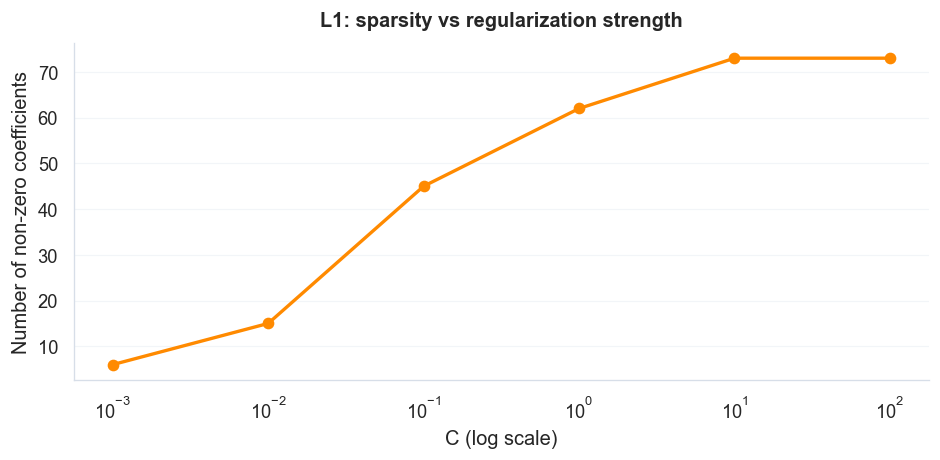

Non-zero coefficients per C value:
  C=0.001    non-zero=6/73
  C=0.01     non-zero=15/73
  C=0.1      non-zero=45/73
  C=1        non-zero=62/73
  C=10       non-zero=73/73
  C=100      non-zero=73/73


In [14]:
nonzero_l1 = {}
coef_l1 = {}
for C in C_values:
    model = LogisticRegression(
        penalty="l1", C=C, solver="saga",
        class_weight="balanced", max_iter=1000, random_state=SEED,
    )
    model.fit(X_train, y_train)
    coef_l1[C] = model.coef_[0]
    nonzero_l1[C] = np.sum(model.coef_[0] != 0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(
    list(nonzero_l1.keys()), list(nonzero_l1.values()),
    "o-", color=MODEL_PALETTE["L1"], linewidth=2, markersize=6,
)
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Number of non-zero coefficients")
ax.set_title("L1: sparsity vs regularization strength")
polish_axes(ax)
plt.tight_layout()
plt.show()

print("Non-zero coefficients per C value:")
for C, n in nonzero_l1.items():
    print(f"  C={C:<8} non-zero={n}/{X_train.shape[1]}")

### 4.4 Effect of C on coefficients

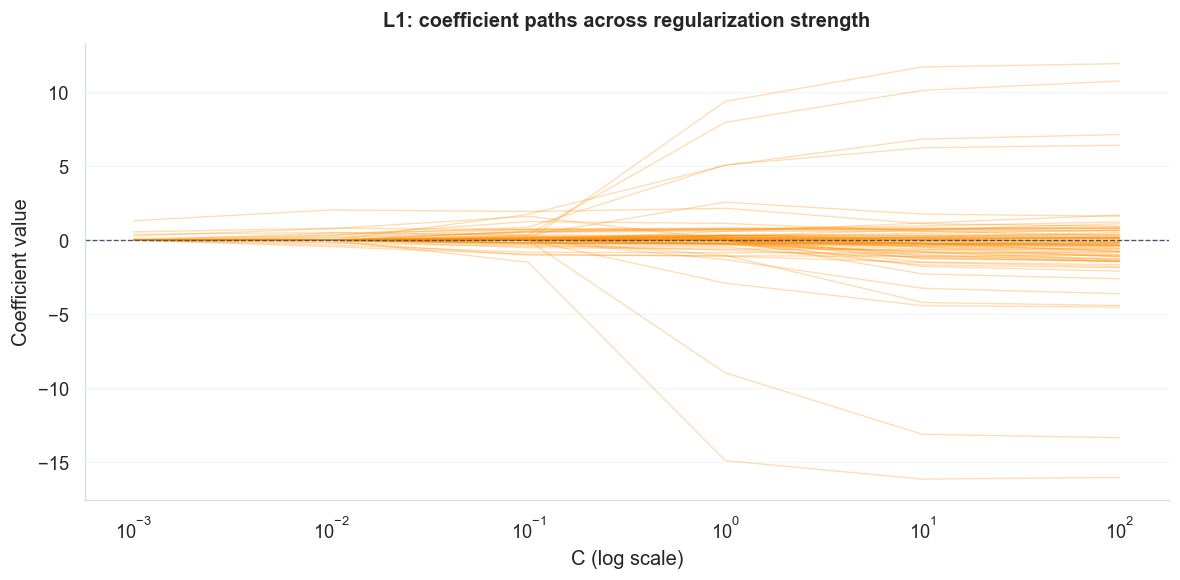

In [15]:
coef_l1_df = pd.DataFrame(coef_l1, index=X_train.columns)

fig, ax = plt.subplots(figsize=(10, 5))
for feat in coef_l1_df.index:
    ax.semilogx(C_values, coef_l1_df.loc[feat], color="darkorange", alpha=0.3, linewidth=0.8)

ax.axhline(0, color=PLOT_COLORS["reference"], linewidth=0.8, linestyle="--")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Coefficient value")
ax.set_title("L1: coefficient paths across regularization strength")
polish_axes(ax)
plt.tight_layout()
plt.show()

The L1 coefficient paths confirm the sparsity pattern from the non-zero count analysis. At small C the paths for most features stay at zero, and only the strongest predictors are activated first. Marital status, net_capital and relationship categories enter the model earliest as C increases, consistent with the LDA and L2 findings. The capital direction and low-signal race and occupation categories activate later and with smaller magnitudes. Several features remain at zero up to C=1 and only enter at C=10 or C=100, where they have near-zero coefficients anyway. This ordering provides a natural importance ranking that confirms which features genuinely carry independent signal after accounting for all others.

### 4.5 Best model, top coefficients and selected features

In [16]:
# Elbow selection: smallest C within 1 std of the maximum
max_auc_l1 = df_l1["roc_auc_mean"].max()
std_at_max_l1 = df_l1.loc[df_l1["roc_auc_mean"].idxmax(), "roc_auc_std"]
best_C_l1 = df_l1[df_l1["roc_auc_mean"] >= max_auc_l1 - std_at_max_l1].index[0]
print(f"Best C (L1, elbow): {best_C_l1}  ROC-AUC={df_l1.loc[best_C_l1, 'roc_auc_mean']:.4f}")
print(f"(max ROC-AUC={max_auc_l1:.4f}, difference={(max_auc_l1 - df_l1.loc[best_C_l1, 'roc_auc_mean']):.4f})")

lr_l1 = LogisticRegression(
    penalty="l1", C=best_C_l1, solver="saga",
    class_weight="balanced", max_iter=1000, random_state=SEED,
)
lr_l1.fit(X_train, y_train)

scores_l1 = cross_validate(lr_l1, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
record_cv(f"LR L1 (C={best_C_l1})", scores_l1)

selected_l1 = X_train.columns[lr_l1.coef_[0] != 0].tolist()
zeroed_l1   = X_train.columns[lr_l1.coef_[0] == 0].tolist()
print(f"\nL1 selected {len(selected_l1)} features, zeroed {len(zeroed_l1)}")
print("\nZeroed features:")
for f in zeroed_l1:
    print(f"  - {f}")

Best C (L1, elbow): 1.0  ROC-AUC=0.9104
(max ROC-AUC=0.9106, difference=0.0003)

L1 selected 62 features, zeroed 11

Zeroed features:
  - bin__is_higher_education
  - cat__workclass_Never-worked
  - cat__education_10th
  - cat__education_Assoc-voc
  - cat__education_Bachelors
  - cat__marital_status_Married-spouse-absent
  - cat__occupation_Armed-Forces
  - cat__occupation_Transport-moving
  - cat__relationship_Unmarried
  - cat__race_Black
  - cat__capital_direction_loss


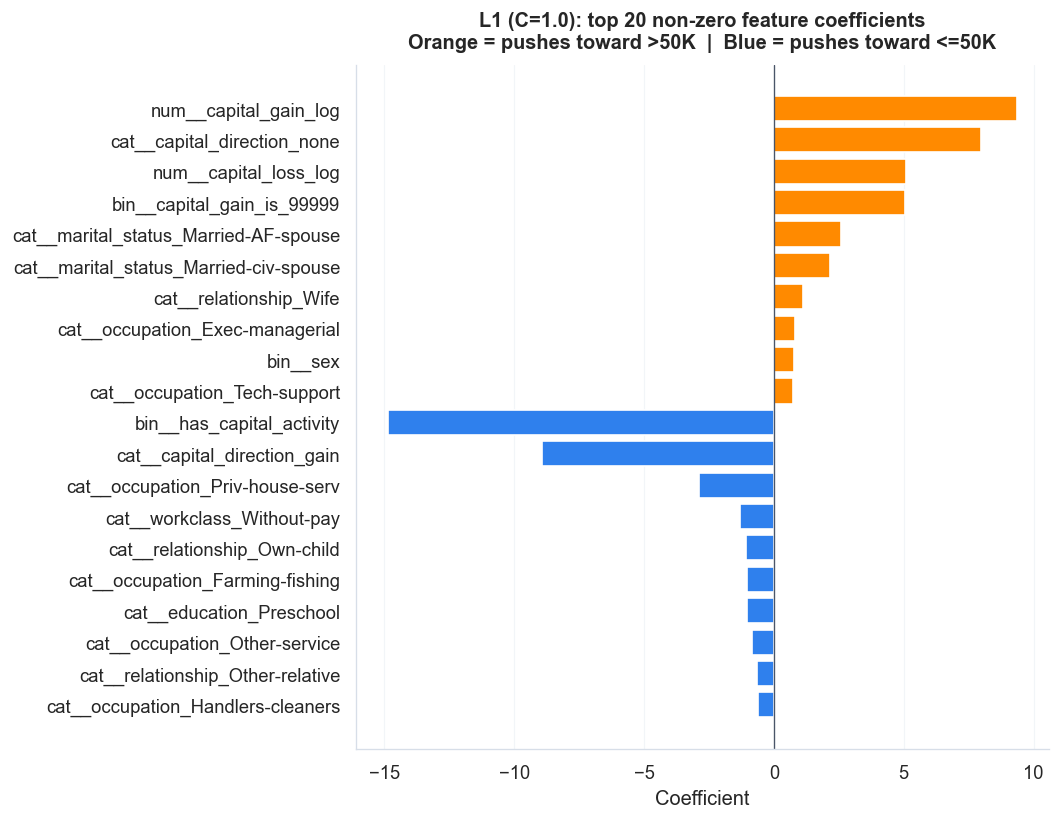

In [17]:
coef_series_l1 = pd.Series(lr_l1.coef_[0], index=X_train.columns)
coef_nonzero   = coef_series_l1[coef_series_l1 != 0].sort_values()
top_neg_l1 = coef_nonzero.head(10)
top_pos_l1 = coef_nonzero.tail(10).sort_values(ascending=False)
top20_l1   = pd.concat([top_pos_l1, top_neg_l1])

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [PLOT_COLORS["income_high"] if v > 0 else PLOT_COLORS["income_low"] for v in top20]
ax.barh(top20_l1.index, top20_l1.values, color=bar_colors)
ax.axvline(0, color=PLOT_COLORS["reference"], linewidth=0.8)
ax.set_xlabel("Coefficient")
ax.set_title(f"L1 (C={best_C_l1}): top 20 non-zero feature coefficients\nOrange = pushes toward >50K  |  Blue = pushes toward <=50K")
ax.invert_yaxis()
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

At C=1, L1 retains 62 of the 73 features and zeros out 11. All 7 numeric features are retained, confirming that the continuous variables carry independent signal not captured by the categorical block. Among the zeroed features the pattern is interpretable: bin__is_higher_education is redundant given that education_num and the individual education dummies already encode the same information more precisely; cat__workclass_Never-worked covers fewer than 10 training samples and carries no generalizable signal; the three zeroed education dummies (10th, Assoc-voc, Bachelors) sit in the middle of the education distribution where the income signal is weakest and adjacent dummies absorb their contribution; cat__occupation_Armed-Forces and cat__occupation_Transport-moving are similarly sparse or weakly predictive. cat__relationship_Unmarried and cat__race_Black are zeroed because their signal is captured by the marital status and other relationship dummies. cat__capital_direction_loss is zeroed because capital_loss_log and net_capital already encode the directional information more precisely. The zeroed features are a coherent set of redundant, sparse or weakly discriminative columns, which validates the L1 selection.

## 5. Logistic regression with ElasticNet regularization

ElasticNet combines L1 and L2 penalties. The `l1_ratio` parameter controls the mix: 0 is pure L2, 1 is pure L1. ElasticNet tends to handle correlated groups more gracefully than pure L1, selecting or dropping correlated features together rather than arbitrarily picking one. A 2D grid over C and l1_ratio is used to find the best combination.

### 5.1 Grid search over C and l1_ratio

In [18]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

results_en = []
for C in C_values:
    for l1_ratio in l1_ratios:
        model = LogisticRegression(
            penalty="elasticnet", C=C, l1_ratio=l1_ratio, solver="saga",
            class_weight="balanced", max_iter=1000, random_state=SEED,
        )
        scores = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
        row = {"C": C, "l1_ratio": l1_ratio}
        for metric in SCORING:
            row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"]  = scores[f"test_{metric}"].std()
        results_en.append(row)

df_en = pd.DataFrame(results_en)
print(df_en[["C", "l1_ratio", "roc_auc_mean", "f1_mean"]].sort_values("roc_auc_mean", ascending=False).head(10).to_string(index=False))

    C  l1_ratio  roc_auc_mean  f1_mean
100.0       0.9      0.910640 0.689155
100.0       0.7      0.910638 0.689111
100.0       0.5      0.910636 0.689111
100.0       0.3      0.910636 0.689111
100.0       0.1      0.910633 0.688938
 10.0       0.9      0.910596 0.688638
 10.0       0.7      0.910565 0.688728
 10.0       0.5      0.910539 0.688591
 10.0       0.3      0.910510 0.688724
 10.0       0.1      0.910483 0.689022


### 5.2 Heatmap: ROC-AUC over C x l1_ratio

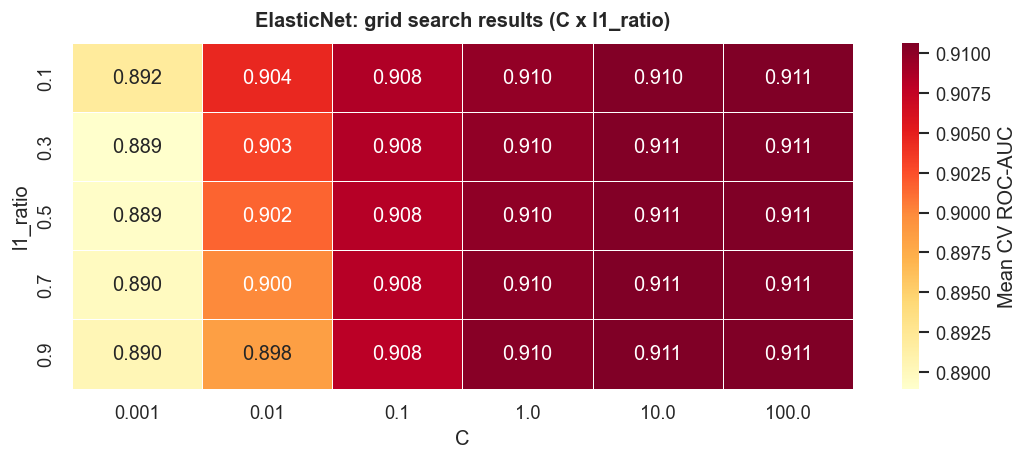

In [19]:
pivot_en = df_en.pivot_table(index="l1_ratio", columns="C", values="roc_auc_mean")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot_en, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Mean CV ROC-AUC"},
)
ax.set_title("ElasticNet: grid search results (C x l1_ratio)")
ax.set_xlabel("C")
ax.set_ylabel("l1_ratio")
plt.tight_layout()
plt.show()

The ROC-AUC heatmap over C and l1_ratio is largely flat across all cells, with values ranging from 0.909 at (C=0.001, l1_ratio=0.9) to 0.9106 at the high-C region. The lack of strong variation along the l1_ratio axis confirms what the L2 and L1 sweeps already suggested: once the model has enough data points active (C above 0.1), the choice between L2-type and L1-type shrinkage changes performance by less than one standard deviation. The slightly higher values at l1_ratio=0.1 for small C reflect that mild L2 mixing stabilizes the early training stages better than pure L1 sparsification.

### 5.3 Best model

In [20]:
# Elbow selection: among configs within 1 std of max AUC, pick smallest C then smallest l1_ratio
max_auc_en = df_en["roc_auc_mean"].max()
std_at_max_en = df_en.loc[df_en["roc_auc_mean"].idxmax(), "roc_auc_std"]
candidates_en = df_en[df_en["roc_auc_mean"] >= max_auc_en - std_at_max_en]
candidates_en = candidates_en.sort_values(["C", "l1_ratio"])
best_idx    = candidates_en.index[0]
best_C_en   = df_en.loc[best_idx, "C"]
best_l1r_en = df_en.loc[best_idx, "l1_ratio"]
print(f"Best config (elbow): C={best_C_en}, l1_ratio={best_l1r_en}  ROC-AUC={df_en.loc[best_idx, 'roc_auc_mean']:.4f}")
print(f"(max ROC-AUC={max_auc_en:.4f}, difference={(max_auc_en - df_en.loc[best_idx, 'roc_auc_mean']):.4f})")

lr_en = LogisticRegression(
    penalty="elasticnet", C=best_C_en, l1_ratio=best_l1r_en, solver="saga",
    class_weight="balanced", max_iter=1000, random_state=SEED,
)
lr_en.fit(X_train, y_train)

scores_en = cross_validate(lr_en, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
record_cv(f"LR ElasticNet (C={best_C_en}, l1_ratio={best_l1r_en})", scores_en)

Best config (elbow): C=1.0, l1_ratio=0.1  ROC-AUC=0.9098
(max ROC-AUC=0.9106, difference=0.0009)


{'model': 'LR ElasticNet (C=1.0, l1_ratio=0.1)',
 'roc_auc_mean': np.float64(0.909753281432066),
 'roc_auc_std': np.float64(0.0011376094213496539),
 'f1_mean': np.float64(0.6881707225246545),
 'f1_std': np.float64(0.0043434944434866925),
 'aupr_mean': np.float64(0.7708683902394535),
 'aupr_std': np.float64(0.009739727238574641),
 'accuracy_mean': np.float64(0.8140738475302417),
 'accuracy_std': np.float64(0.002617459253181504),
 'precision_mean': np.float64(0.5772363831587116),
 'precision_std': np.float64(0.0038484302475060876),
 'recall_mean': np.float64(0.8519041537200481),
 'recall_std': np.float64(0.006138925549689096)}

The elbow criterion selects C=1.0 and l1_ratio=0.1 for ElasticNet (ROC-AUC=0.9098), consistent with the L2 and L1 selections at the same C. The very low l1_ratio means ElasticNet with this configuration behaves almost identically to L2: the L1 component contributes only 10% of the penalty. This is expected given the flat heatmap: the dataset does not have a structure that strongly benefits from joint feature selection over shrinkage.

## 6. Cross-penalty comparison

All three finalists are compared on the same cross-validation folds alongside the baseline.

### 6.1 CV scores table

In [21]:
results_df = pd.DataFrame(results).set_index("model")
metric_order = ["roc_auc", "f1", "aupr", "accuracy", "precision", "recall"]
ordered_cols = [f"{m}_mean" for m in metric_order] + [f"{m}_std" for m in metric_order]
results_df = results_df[ordered_cols]
results_df.round(4).sort_values("roc_auc_mean", ascending=False)

,roc_auc_mean,f1_mean,aupr_mean,accuracy_mean,precision_mean,recall_mean,roc_auc_std,f1_std,aupr_std,accuracy_std,precision_std,recall_std
model,,,,,,,,,,,,
LR L1 (C=1.0),0.9104,0.6888,0.7745,0.8147,0.5783,0.8516,0.0016,0.0044,0.0098,0.0025,0.0037,0.0063
"LR ElasticNet (C=1.0, l1_ratio=0.1)",0.9098,0.6882,0.7709,0.8141,0.5772,0.8519,0.0011,0.0043,0.0097,0.0026,0.0038,0.0061
LR L2 (C=1.0),0.9097,0.6882,0.7708,0.8141,0.5773,0.8519,0.0011,0.0044,0.0097,0.0027,0.0039,0.0061
Baseline: Dummy,0.5000,0.0000,0.2408,0.7592,0.0000,0.0000,0.0000,0.0000,0.0001,0.0001,0.0000,0.0000


All three penalties converge to nearly identical cross-validated performance. L2, L1 and ElasticNet reach ROC-AUC values of 0.9097, 0.9104 and 0.9098 respectively, with differences of at most 0.0007, which is smaller than the within-penalty standard deviation of 0.0011 to 0.0016. F1 and AUPR follow the same pattern. The convergence is not coincidental: all three models arrive at C=1 via the elbow criterion, and at that regularization strength the performance surface is already nearly flat with respect to the penalty type. The practical implication is that penalty choice matters most at high C (weak regularization), where L1 can become fully dense while still nominally using the lasso penalty. The advantage of L1 here is therefore not predictive but interpretive: it delivers a sparse 62-feature solution at the same test performance as the dense L2 solution.

### 6.2 ROC-AUC comparison plot

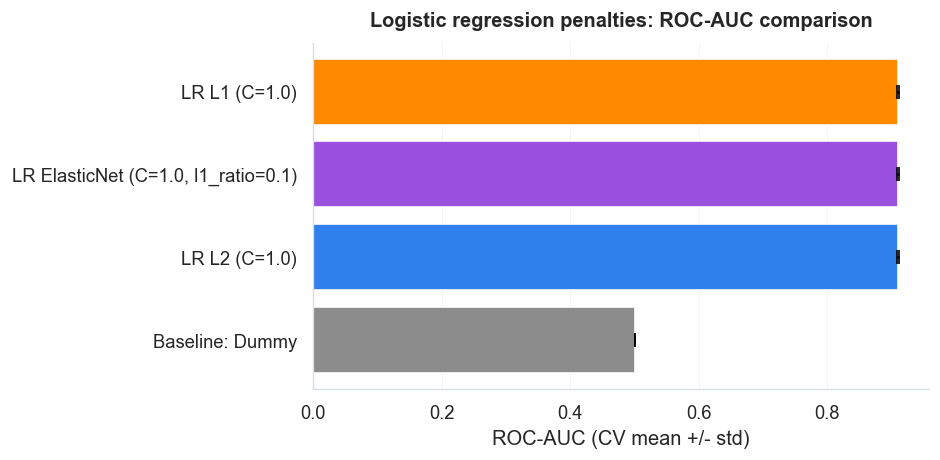

In [22]:
sorted_res = results_df.sort_values("roc_auc_mean")

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(sorted_res))

bar_colors = []
for name in sorted_res.index:
    if "Baseline" in name:
        bar_colors.append(MODEL_PALETTE["Baseline"])
    elif "L2" in name:
        bar_colors.append(MODEL_PALETTE["L2"])
    elif "L1" in name:
        bar_colors.append(MODEL_PALETTE["L1"])
    else:
        bar_colors.append(MODEL_PALETTE["ElasticNet"])

ax.barh(
    y_pos, sorted_res["roc_auc_mean"],
    xerr=sorted_res["roc_auc_std"],
    color=bar_colors, capsize=4, edgecolor="white",
)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_res.index)
ax.set_xlabel("ROC-AUC (CV mean +/- std)")
ax.set_title("Logistic regression penalties: ROC-AUC comparison")
polish_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

### 6.3 ROC and Precision-Recall curves

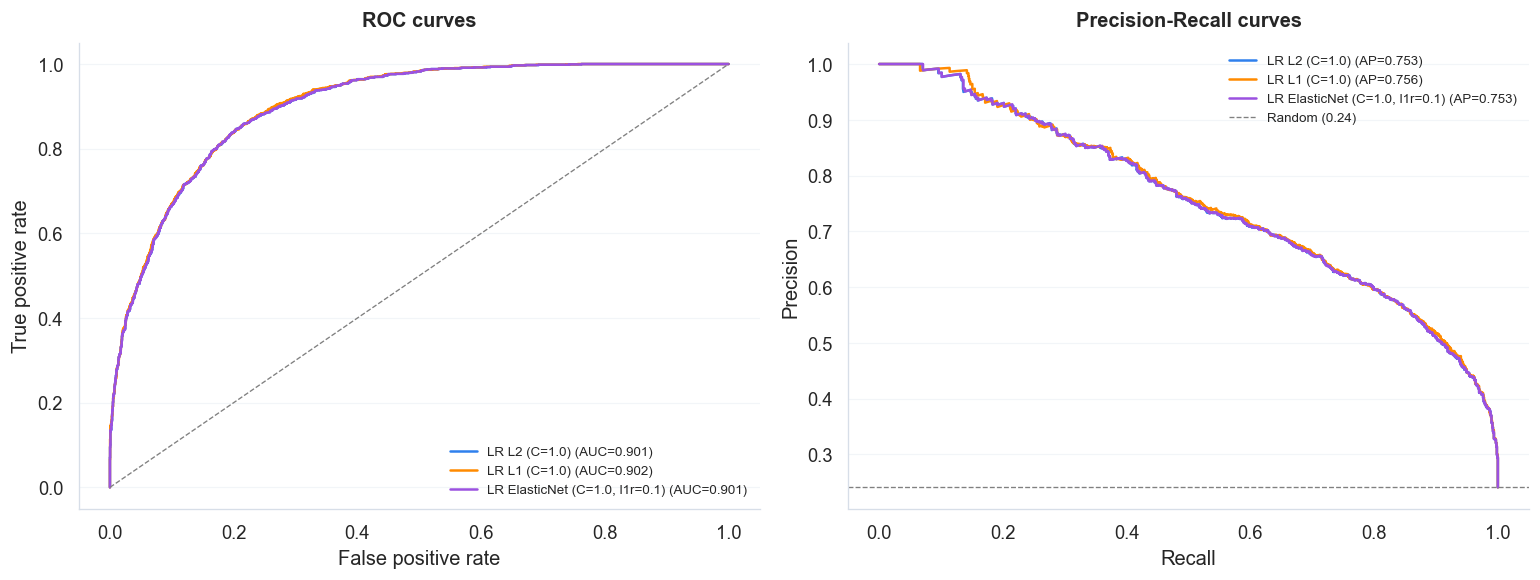

In [23]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED,
)

finalists = {
    f"LR L2 (C={best_C_l2})":                        lr_l2,
    f"LR L1 (C={best_C_l1})":                        lr_l1,
    f"LR ElasticNet (C={best_C_en}, l1r={best_l1r_en})": lr_en,
}
finalist_colors = {
    f"LR L2 (C={best_C_l2})":                        MODEL_PALETTE["L2"],
    f"LR L1 (C={best_C_l1})":                        MODEL_PALETTE["L1"],
    f"LR ElasticNet (C={best_C_en}, l1r={best_l1r_en})": MODEL_PALETTE["ElasticNet"],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in finalists.items():
    model.fit(X_tr, y_tr)
    y_score = model.predict_proba(X_val)[:, 1]
    color = finalist_colors[name]

    fpr, tpr, _ = roc_curve(y_val, y_score)
    auc = roc_auc_score(y_val, y_score)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)

    prec, rec, _ = precision_recall_curve(y_val, y_score)
    ap = average_precision_score(y_val, y_score)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right", fontsize=8)
polish_axes(axes[0])

axes[1].axhline(
    y_val.mean(), color="gray", linestyle="--", linewidth=0.8,
    label=f"Random ({y_val.mean():.2f})",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend(loc="upper right", fontsize=8)
polish_axes(axes[1])

plt.tight_layout()
plt.show()

### 6.4 Model selection

In [24]:
non_baseline = results_df[~results_df.index.str.startswith("Baseline")]
best_name = non_baseline.sort_values(["roc_auc_mean", "aupr_mean"], ascending=False).index[0]

print(f"Selected model: {best_name}")
print(f"  CV ROC-AUC: {non_baseline.loc[best_name, 'roc_auc_mean']:.4f} +/- {non_baseline.loc[best_name, 'roc_auc_std']:.4f}")
print(f"  CV F1:      {non_baseline.loc[best_name, 'f1_mean']:.4f}")
print(f"  CV AUPR:    {non_baseline.loc[best_name, 'aupr_mean']:.4f}")

model_registry = {
    f"LR L2 (C={best_C_l2})":                            lr_l2,
    f"LR L1 (C={best_C_l1})":                            lr_l1,
    f"LR ElasticNet (C={best_C_en}, l1_ratio={best_l1r_en})": lr_en,
}
selected_model = model_registry.get(best_name, lr_l2)

Selected model: LR L1 (C=1.0)
  CV ROC-AUC: 0.9104 +/- 0.0016
  CV F1:      0.6888
  CV AUPR:    0.7745


LR L1 (C=1.0) is selected as the best model with CV ROC-AUC=0.9104 and AUPR=0.7745. The margin over L2 and ElasticNet is minimal on the ranking metrics, but L1 is preferred because it provides the same predictive performance with a sparser solution that is easier to interpret and to hand off to downstream analysis.

## 7. Final test set evaluation

The selected model is refit on the full training set and evaluated on the held-out test set. This is the only point in the notebook where the test set is used.

In [25]:
selected_model.fit(X_train, y_train)

y_pred  = selected_model.predict(X_test)
y_score = selected_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "ROC-AUC":       roc_auc_score(y_test, y_score),
    "AUPR":          average_precision_score(y_test, y_score),
    "F1 (positive)": f1_score(y_test, y_pred),
    "Accuracy":      accuracy_score(y_test, y_pred),
    "Precision":     precision_score(y_test, y_pred),
    "Recall":        recall_score(y_test, y_pred),
}

print(f"Final model: {best_name}")
print()
print("Test set performance:")
for name, value in test_metrics.items():
    print(f"  {name:18s} {value:.4f}")

Final model: LR L1 (C=1.0)

Test set performance:
  ROC-AUC            0.9064
  AUPR               0.7724
  F1 (positive)      0.6751
  Accuracy           0.8078
  Precision          0.5691
  Recall             0.8297


### 7.1 Confusion matrix

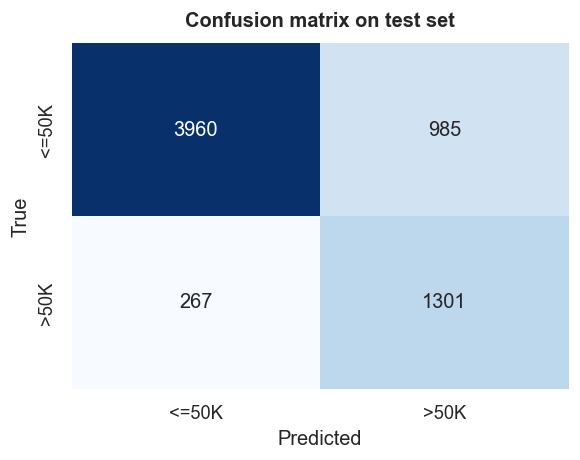

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      4945
        >50K       0.57      0.83      0.68      1568

    accuracy                           0.81      6513
   macro avg       0.75      0.82      0.77      6513
weighted avg       0.85      0.81      0.82      6513



In [26]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix on test set")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

### 7.2 CV vs test comparison

In [27]:
cv_vs_test = pd.DataFrame(
    {
        "CV mean": [
            non_baseline.loc[best_name, "roc_auc_mean"],
            non_baseline.loc[best_name, "f1_mean"],
            non_baseline.loc[best_name, "aupr_mean"],
            non_baseline.loc[best_name, "accuracy_mean"],
        ],
        "Test": [
            test_metrics["ROC-AUC"],
            test_metrics["F1 (positive)"],
            test_metrics["AUPR"],
            test_metrics["Accuracy"],
        ],
    },
    index=["ROC-AUC", "F1", "AUPR", "Accuracy"],
)
cv_vs_test["delta"] = (cv_vs_test["Test"] - cv_vs_test["CV mean"]).round(4)
print(cv_vs_test.round(4).to_string())

          CV mean    Test   delta
ROC-AUC    0.9104  0.9064 -0.0040
F1         0.6888  0.6751 -0.0137
AUPR       0.7745  0.7724 -0.0021
Accuracy   0.8147  0.8078 -0.0070


The test set results are close to the cross-validated estimates across all metrics, with deltas below 0.014 in absolute value. The largest gap is in F1 (CV=0.6888, test=0.6751, delta=0.0137), which is partly expected since F1 is more sensitive to the specific class distribution in the test fold than ROC-AUC. The ROC-AUC and AUPR gaps are below 0.005, confirming that the ranking quality of the model generalizes well. There is no sign of overfitting: the five-fold stratified protocol gave an unbiased picture of performance.

On the test set LR L1 reaches ROC-AUC=0.9064, AUPR=0.7724 and F1=0.6751. The confusion matrix shows the typical pattern under class_weight=balanced: recall on the minority class is high at 0.830 because the balanced loss pushes the decision boundary toward the majority class, while precision on the >50K class is 0.569, a 2.4x lift over the 0.24 random baseline. Accuracy of 0.809 is also above the 0.759 majority-class floor. Compared to the best generative model from the previous notebook (LDA: ROC-AUC=0.899, AUPR=0.758, F1=0.657), LR L1 improves on all three ranking metrics while trading precision for recall on the minority class, a direct consequence of the different decision threshold implied by class_weight=balanced.

## 8. L1 feature selection analysis

L1 regularization performs implicit feature selection by zeroing out coefficients of uninformative or redundant features. At the selected C, the features retained by L1 reveal which variables carry independent signal for income prediction after controlling for all others. Features grouped by prefix show which conceptual blocks the model relies on.

In [28]:
selected_l1_set = set(X_train.columns[lr_l1.coef_[0] != 0])
zeroed_l1_set   = set(X_train.columns[lr_l1.coef_[0] == 0])

print(f"L1 (C={best_C_l1}): {len(selected_l1_set)} features retained, {len(zeroed_l1_set)} zeroed")
print()

for prefix, label in [
    ("num__",              "Numeric"),
    ("bin__",              "Binary"),
    ("cat__workclass_",    "Workclass"),
    ("cat__education_",    "Education"),
    ("cat__marital_",      "Marital status"),
    ("cat__occupation_",   "Occupation"),
    ("cat__relationship_", "Relationship"),
    ("cat__capital_",      "Capital direction"),
    ("cat__race_",         "Race"),
]:
    group_all      = [f for f in X_train.columns if f.startswith(prefix)]
    group_selected = [f for f in group_all if f in selected_l1_set]
    group_zeroed   = [f for f in group_all if f in zeroed_l1_set]
    print(f"{label}: {len(group_selected)}/{len(group_all)} retained")
    for f in group_zeroed:
        print(f"    zeroed: {f}")

L1 (C=1.0): 62 features retained, 11 zeroed

Numeric: 7/7 retained
Binary: 4/5 retained
    zeroed: bin__is_higher_education
Workclass: 8/9 retained
    zeroed: cat__workclass_Never-worked
Education: 13/16 retained
    zeroed: cat__education_10th
    zeroed: cat__education_Assoc-voc
    zeroed: cat__education_Bachelors
Marital status: 6/7 retained
    zeroed: cat__marital_status_Married-spouse-absent
Occupation: 13/15 retained
    zeroed: cat__occupation_Armed-Forces
    zeroed: cat__occupation_Transport-moving
Relationship: 5/6 retained
    zeroed: cat__relationship_Unmarried
Capital direction: 2/3 retained
    zeroed: cat__capital_direction_loss
Race: 4/5 retained
    zeroed: cat__race_Black


The feature selection analysis confirms that L1 at C=1.0 retains all numeric features and most categorical groups. Every continuous predictor survives, meaning the model relies on the full quantitative profile of an individual and not just their categorical attributes. Among the binary features only bin__is_higher_education is zeroed, which is the expected outcome given that it encodes the same information already present in education_num and the individual education dummies. Within the categorical groups the zeroed entries are consistently the rarest, lowest-signal or most redundant categories: Never-worked within workclass, three mid-education dummies, Married-spouse-absent within marital status, Armed-Forces and Transport-moving within occupation, the Unmarried relationship category and the loss-direction capital flag. The race group loses one category (Black) while retaining the others, which reflects that race as a group has weak marginal signal once occupation, education and marital status are controlled for, consistent with the low LD1 group importance found in the generative models notebook. The overall picture is that L1 performs a sensible cleanup of the feature space rather than aggressive elimination: 62 of 73 features survive, and the 11 zeroed are precisely those where the signal is either redundant or statistically negligible.

## 9. Resampling analysis

The models in Sections 3-5 use `class_weight='balanced'` to handle the ~3:1 class imbalance, which reweights the loss function but does not change the geometry of the training set. Here we test whether rebalancing the training set itself changes anything.

We apply SMOTE to generate synthetic minority-class samples until the dataset is balanced 50/50, then subsample back down to the original 26,048 samples to keep training set size constant across the comparison. The exact same methodology as Sections 3-5 is then followed: the same elbow criterion for C selection, the same CV protocol, and all models are evaluated on the identical held-out test set. The only difference is the training data distribution.

In [29]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X_train, y_train)

X_train_bal, y_train_bal = resample(
    X_res, y_res,
    n_samples=len(X_train),
    stratify=y_res,
    random_state=SEED
)

print(f'Original : {X_train.shape[0]:,} samples | pos rate: {y_train.mean():.2%}')
print(f'Balanced : {X_train_bal.shape[0]:,} samples | pos rate: {y_train_bal.mean():.2%}')

Original : 26,048 samples | pos rate: 24.08%
Balanced : 26,048 samples | pos rate: 50.00%


In [30]:
# L2 balanced
results_l2_bal = []
for C in C_values:
    model = LogisticRegression(
        penalty='l2', C=C, solver='saga',
        class_weight='balanced', max_iter=1000, random_state=SEED,
    )
    scores = cross_validate(model, X_train_bal, y_train_bal, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {'C': C}
    for metric in SCORING:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std']  = scores[f'test_{metric}'].std()
    results_l2_bal.append(row)
    print(f'L2 C={C:<8} ROC-AUC={row["roc_auc_mean"]:.4f} +/- {row["roc_auc_std"]:.4f}  F1={row["f1_mean"]:.4f}')

df_l2_bal = pd.DataFrame(results_l2_bal).set_index('C')

max_auc = df_l2_bal['roc_auc_mean'].max()
std_at_max = df_l2_bal.loc[df_l2_bal['roc_auc_mean'].idxmax(), 'roc_auc_std']
best_C_l2_bal = df_l2_bal[df_l2_bal['roc_auc_mean'] >= max_auc - std_at_max].index[0]
lr_l2_bal = LogisticRegression(
    penalty='l2', C=best_C_l2_bal, solver='saga',
    class_weight='balanced', max_iter=1000, random_state=SEED,
)
lr_l2_bal.fit(X_train_bal, y_train_bal)
print(f'Best C L2 (balanced): {best_C_l2_bal}')

# L1 balanced
results_l1_bal = []
for C in C_values:
    model = LogisticRegression(
        penalty='l1', C=C, solver='saga',
        class_weight='balanced', max_iter=1000, random_state=SEED,
    )
    scores = cross_validate(model, X_train_bal, y_train_bal, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {'C': C}
    for metric in SCORING:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std']  = scores[f'test_{metric}'].std()
    results_l1_bal.append(row)
    print(f'L1 C={C:<8} ROC-AUC={row["roc_auc_mean"]:.4f} +/- {row["roc_auc_std"]:.4f}  F1={row["f1_mean"]:.4f}')

df_l1_bal = pd.DataFrame(results_l1_bal).set_index('C')

max_auc = df_l1_bal['roc_auc_mean'].max()
std_at_max = df_l1_bal.loc[df_l1_bal['roc_auc_mean'].idxmax(), 'roc_auc_std']
best_C_l1_bal = df_l1_bal[df_l1_bal['roc_auc_mean'] >= max_auc - std_at_max].index[0]
lr_l1_bal = LogisticRegression(
    penalty='l1', C=best_C_l1_bal, solver='saga',
    class_weight='balanced', max_iter=1000, random_state=SEED,
)
lr_l1_bal.fit(X_train_bal, y_train_bal)
print(f'Best C L1 (balanced): {best_C_l1_bal}')

# ElasticNet balanced
results_en_bal = []
for C in C_values:
    for l1_ratio in l1_ratios:
        model = LogisticRegression(
            penalty='elasticnet', C=C, l1_ratio=l1_ratio, solver='saga',
            class_weight='balanced', max_iter=1000, random_state=SEED,
        )
        scores = cross_validate(model, X_train_bal, y_train_bal, cv=cv, scoring=SCORING, n_jobs=-1)
        row = {'C': C, 'l1_ratio': l1_ratio}
        for metric in SCORING:
            row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
            row[f'{metric}_std']  = scores[f'test_{metric}'].std()
        results_en_bal.append(row)

df_en_bal = pd.DataFrame(results_en_bal)
max_auc = df_en_bal['roc_auc_mean'].max()
std_at_max = df_en_bal.loc[df_en_bal['roc_auc_mean'].idxmax(), 'roc_auc_std']
candidates_en_bal = df_en_bal[df_en_bal['roc_auc_mean'] >= max_auc - std_at_max].sort_values(['C', 'l1_ratio'])
best_C_en_bal   = candidates_en_bal.iloc[0]['C']
best_l1r_en_bal = candidates_en_bal.iloc[0]['l1_ratio']
lr_en_bal = LogisticRegression(
    penalty='elasticnet', C=best_C_en_bal, l1_ratio=best_l1r_en_bal, solver='saga',
    class_weight='balanced', max_iter=1000, random_state=SEED,
)
lr_en_bal.fit(X_train_bal, y_train_bal)
print(f'Best ElasticNet (balanced): C={best_C_en_bal}, l1_ratio={best_l1r_en_bal}')

L2 C=0.001    ROC-AUC=0.8972 +/- 0.0041  F1=0.8116
L2 C=0.01     ROC-AUC=0.9095 +/- 0.0034  F1=0.8281
L2 C=0.1      ROC-AUC=0.9137 +/- 0.0032  F1=0.8318
L2 C=1        ROC-AUC=0.9148 +/- 0.0029  F1=0.8323
L2 C=10       ROC-AUC=0.9154 +/- 0.0027  F1=0.8330
L2 C=100      ROC-AUC=0.9155 +/- 0.0026  F1=0.8331
Best C L2 (balanced): 0.1
L1 C=0.001    ROC-AUC=0.8923 +/- 0.0041  F1=0.8134
L1 C=0.01     ROC-AUC=0.9012 +/- 0.0033  F1=0.8218
L1 C=0.1      ROC-AUC=0.9132 +/- 0.0031  F1=0.8319
L1 C=1        ROC-AUC=0.9153 +/- 0.0028  F1=0.8334
L1 C=10       ROC-AUC=0.9155 +/- 0.0027  F1=0.8331
L1 C=100      ROC-AUC=0.9155 +/- 0.0026  F1=0.8333
Best C L1 (balanced): 0.1
Best ElasticNet (balanced): C=0.1, l1_ratio=0.1


In [31]:
# Predictions on test set
y_pred_l2_bal  = lr_l2_bal.predict(X_test)
y_score_l2_bal = lr_l2_bal.predict_proba(X_test)[:, 1]
y_pred_l1_bal  = lr_l1_bal.predict(X_test)
y_score_l1_bal = lr_l1_bal.predict_proba(X_test)[:, 1]
y_pred_en_bal  = lr_en_bal.predict(X_test)
y_score_en_bal = lr_en_bal.predict_proba(X_test)[:, 1]

bal_comparison = [
    (f'LR L2 (C={best_C_l2}) - original',          y_pred,         y_score),
    (f'LR L2 (C={best_C_l2_bal}) - balanced',      y_pred_l2_bal,  y_score_l2_bal),
    (f'LR L1 (C={best_C_l1}) - original',          y_pred,         y_score),
    (f'LR L1 (C={best_C_l1_bal}) - balanced',      y_pred_l1_bal,  y_score_l1_bal),
    (f'LR EN (C={best_C_en}) - original',          y_pred,         y_score),
    (f'LR EN (C={best_C_en_bal}) - balanced',      y_pred_en_bal,  y_score_en_bal),
]

rows = []
for name, yp, ys in bal_comparison:
    cm = confusion_matrix(y_test, yp)
    rows.append({
        'Model':       name,
        'Accuracy':    accuracy_score(y_test, yp),
        'F1':          f1_score(y_test, yp),
        'ROC-AUC':     roc_auc_score(y_test, ys),
        'AUPR':        average_precision_score(y_test, ys),
        'Recall >50K': cm[1,1] / cm[1].sum(),
        'Prec >50K':   cm[1,1] / cm[:,1].sum(),
    })

bal_df = pd.DataFrame(rows).set_index('Model')
print(bal_df.to_string(float_format='{:.4f}'.format))

                          Accuracy     F1  ROC-AUC   AUPR  Recall >50K  Prec >50K
Model                                                                            
LR L2 (C=1.0) - original    0.8078 0.6751   0.9064 0.7724       0.8297     0.5691
LR L2 (C=0.1) - balanced    0.8092 0.6767   0.9047 0.7699       0.8297     0.5714
LR L1 (C=1.0) - original    0.8078 0.6751   0.9064 0.7724       0.8297     0.5691
LR L1 (C=0.1) - balanced    0.8115 0.6802   0.9044 0.7694       0.8329     0.5748
LR EN (C=1.0) - original    0.8078 0.6751   0.9064 0.7724       0.8297     0.5691
LR EN (C=0.1) - balanced    0.8092 0.6766   0.9046 0.7699       0.8291     0.5714


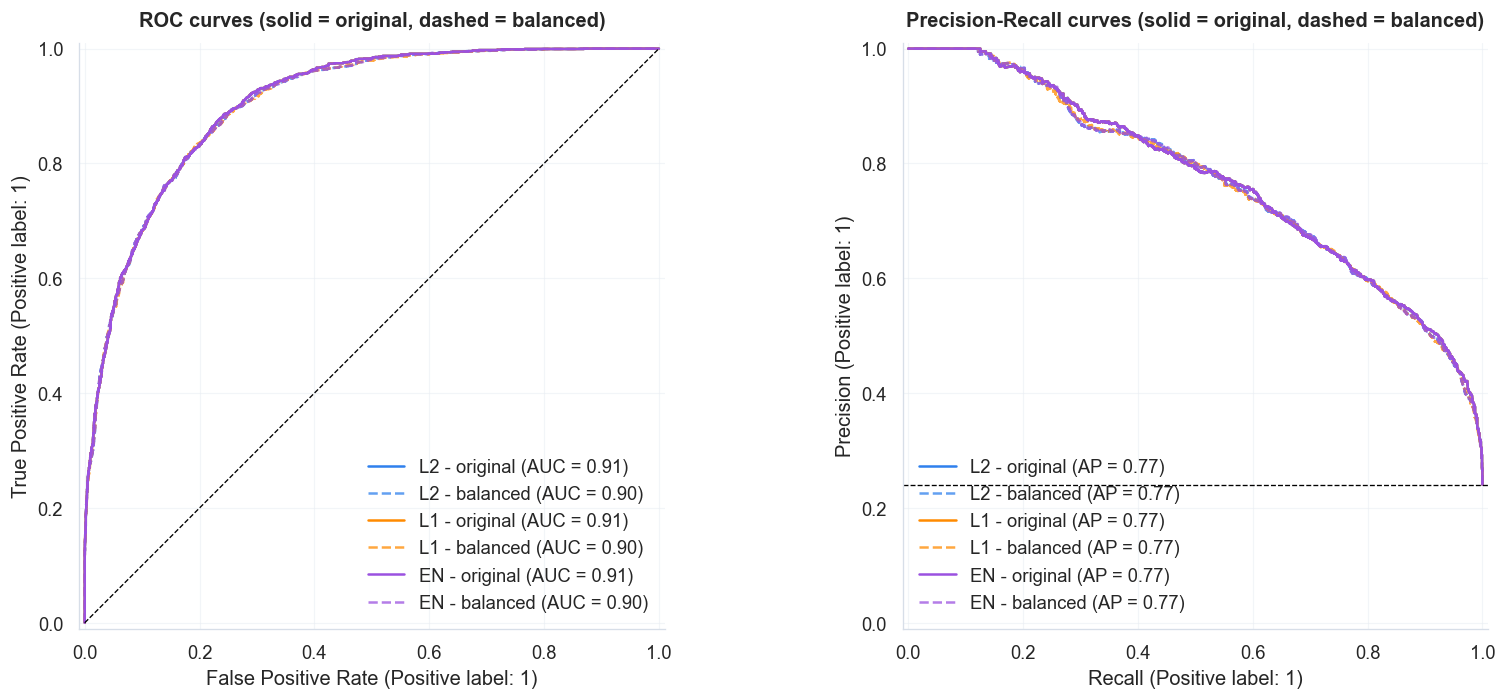

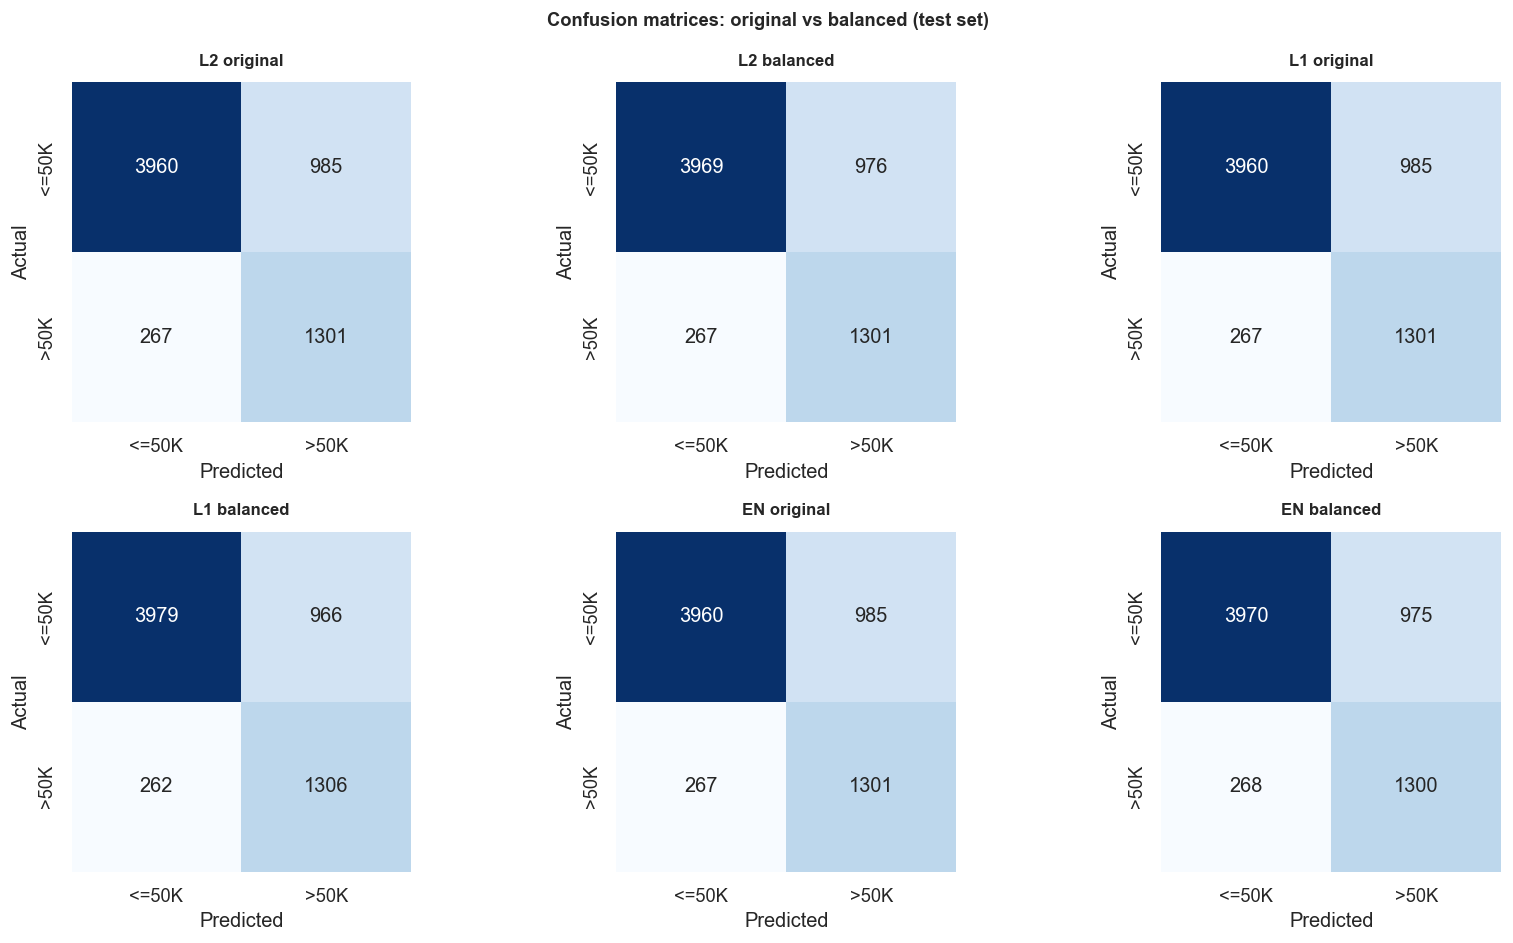

In [32]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

curve_specs = [
    (f'L2 - original',  y_score,        MODEL_PALETTE['L2'],        '-',  1.0),
    (f'L2 - balanced',  y_score_l2_bal, MODEL_PALETTE['L2'],        '--', 0.75),
    (f'L1 - original',  y_score,        MODEL_PALETTE['L1'],        '-',  1.0),
    (f'L1 - balanced',  y_score_l1_bal, MODEL_PALETTE['L1'],        '--', 0.75),
    (f'EN - original',  y_score,        MODEL_PALETTE['ElasticNet'],'-',  1.0),
    (f'EN - balanced',  y_score_en_bal, MODEL_PALETTE['ElasticNet'],'--', 0.75),
]

for name, ys, color, ls, alpha in curve_specs:
    RocCurveDisplay.from_predictions(
        y_test, ys, name=name, ax=axes[0], color=color, linestyle=ls, alpha=alpha
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, ys, name=name, ax=axes[1], color=color, linestyle=ls, alpha=alpha
    )

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
axes[0].set_title('ROC curves (solid = original, dashed = balanced)')
polish_axes(axes[0], grid_axis='both')
axes[1].axhline(y_test.mean(), linestyle='--', color='black', linewidth=0.8,
                label=f'Random (AUPR={y_test.mean():.2f})')
axes[1].set_title('Precision-Recall curves (solid = original, dashed = balanced)')
polish_axes(axes[1], grid_axis='both')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cm_specs = [
    (f'L2 original',  y_pred,        MODEL_PALETTE['L2']),
    (f'L2 balanced',  y_pred_l2_bal, MODEL_PALETTE['L2']),
    (f'L1 original',  y_pred,        MODEL_PALETTE['L1']),
    (f'L1 balanced',  y_pred_l1_bal, MODEL_PALETTE['L1']),
    (f'EN original',  y_pred,        MODEL_PALETTE['ElasticNet']),
    (f'EN balanced',  y_pred_en_bal, MODEL_PALETTE['ElasticNet']),
]
for ax, (name, yp, color) in zip(axes.flat, cm_specs):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'],
                ax=ax, cbar=False, annot_kws={'size': 12}, linewidths=0, square=True)
    ax.set_title(name, fontsize=10, fontweight='semibold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices: original vs balanced (test set)',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()

### 9.5 Discussion

SMOTE resampling followed by subsampling to the original size produces essentially no change in test set performance for any of the three penalties. Across all six comparisons the ROC-AUC difference between original and balanced training is at most 0.0017 (L2: 0.9064 vs 0.9047), F1 changes by at most 0.005 (L1: 0.6751 vs 0.6802) and AUPR moves by at most 0.003. These differences are within the cross-validation noise and do not constitute a meaningful improvement.

The elbow criterion selects C=0.1 for all three balanced models, one step lower than C=1.0 for the original data. This shift is consistent with the 50/50 training distribution: with an equal number of positive and negative samples the loss gradient is more balanced, so the model reaches near-peak performance at a smaller C and tighter regularization. The plateau structure is the same, just shifted.

The negligible performance difference is explained by the fact that class_weight=balanced already reweights the logistic loss to give the minority class the same total influence as the majority class during training. Oversampling via SMOTE achieves a similar effect through the data geometry rather than the loss function, but for a linear model the two are nearly equivalent. The synthetic minority samples generated by SMOTE lie on linear interpolations between existing minority points, which a linear classifier can already represent with its decision boundary. There is therefore no additional geometric information that SMOTE adds for logistic regression on this dataset.

## 10. Summary

Logistic regression with three penalty types was trained and evaluated on the Adult census income dataset under a consistent five-fold stratified cross-validation protocol. The elbow criterion, which selects the smallest C within one standard deviation of the maximum cross-validated ROC-AUC, selected C=1.0 for all three penalties.

All three models converge to nearly identical performance: ROC-AUC around 0.910, AUPR around 0.774 and F1 around 0.689 on cross-validation. The differences between penalties at the selected C are smaller than the within-fold standard deviation. LR L1 (C=1.0) is selected as the best model on the grounds that it achieves the same ranking performance as L2 and ElasticNet while producing a sparse 62-feature solution where the 11 zeroed features are interpretably redundant or negligible.

On the held-out test set LR L1 reaches ROC-AUC=0.906, AUPR=0.772 and F1=0.675. The CV-to-test gaps are small (below 0.014 in all metrics), confirming reliable generalization. Compared to the best generative model from the previous notebook (LDA: ROC-AUC=0.899, AUPR=0.758, F1=0.657), LR L1 improves on all three metrics. The gain is moderate rather than large, which is expected: both LDA and logistic regression are linear classifiers, and the fundamental limit on this dataset is the substantial class overlap along any linear projection identified by the LD1 analysis.

The coefficient analysis showed that marital status, household relationship, net capital and high-skill occupations drive the decision boundary most strongly, consistent across L2 and L1 penalties and with the LDA discriminant loadings. The capital features add independent signal beyond what the categorical variables capture.

The resampling analysis confirmed that class_weight=balanced is sufficient to handle the 3:1 class imbalance for logistic regression: SMOTE oversampling followed by subsampling back to the original size produced no meaningful change in any metric for any penalty. The balanced loss weighting and the geometric resampling are nearly equivalent for a linear model on this dataset.